# Phase 1: Supervised Learning

### **Project Integration**
We are training this model to predict the likelihood of liver disease based on patient features. These predictions are used as a decision-support signal within the advice system, helping determine whether to suggest a “Consult a hepatologist” recommendation or a “Routine check-up” reminder. The system is designed to assist professional medical judgment.

---
## Model 1: Random Forest
###  Model Selection Rationale

* **Handling Non-linear Medical Data:** Medical biomarkers like Bilirubin and Liver Enzymes often have non-linear relationships with disease; Random Forest captures these "threshold" patterns. Often more effectively than linear models.
* **Ensemble Robustness:** By aggregating results from multiple decision trees, Random Forest significantly reduces the risk of overfitting, which is critical when working with relatively small datasets (~583 rows).
* **Feature Interpretability:** This model provides "Feature Importance" scores. This helps us interpret which variables most influence model predictions.
* **Minimal Data Scaling:** While we applied scaling for consistency across team models, Random Forest is naturally robust against the wide numerical ranges found in medical lab results.

#### **Strengths**
* **Robust to Noise:** Effectively handles outliers in medical lab results.
* **High Predictive Power:** Captures complex interactions between different liver enzymes.
* **Built-in Generalization:** Uses bagging (Bootstrap Aggregating), where multiple trees are trained on random subsets of the data and their predictions are combined, reducing variance and improving model stability.

#### **Weaknesses**
* **Complexity in Visualization:** More difficult to visualize than a single Decision Tree or Logistic Regression.
* **Memory Usage:** Can become computationally expensive if the number of trees ($n\_estimators$) is too high.


**Data Preprocessing & Splitting**
In this stage, we load the preprocessed medical data and handle the final formatting required for the Random Forest algorithm. We use a stratified split to maintain the ratio of liver disease cases across our training and testing sets, ensuring a reliable evaluation of the model's performance on the minority class.

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load already split datasets 

X_train = pd.read_csv("Preprocessed_Data/X_train.csv")
y_train = pd.read_csv("Preprocessed_Data/y_train.csv")

X_test = pd.read_csv("Preprocessed_Data/X_test.csv")
y_test = pd.read_csv("Preprocessed_Data/y_test.csv")

# Convert target to Series 
y_train = y_train.squeeze()
y_test = y_test.squeeze()



# Scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### **Hyperparameter Tuning via GridSearchCV**
To refine the system for meaningful medical predictions, we perform a grid search over key hyperparameters such as `n_estimators` and `max_depth`. We use **5-fold cross-validation** and optimize for the **F1-Score** to ensure the model maintains a scientific balance between precision and recall, reducing the risk of overfitting on the training data.

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# GridSearchCV to refine the system
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_rf.fit(X_train_scaled, y_train)
best_rf = grid_rf.best_estimator_



### **Final Evaluation & Decision Thresholding**
In this final stage, we evaluate the optimized model's performance on the unseen test set. To prioritize medical safety, we manually adjust the **decision threshold to 0.35**, shifting the model’s focus toward **Recall**. This ensures the system is highly sensitive to liver disease cases, which is critical for an advice system suggesting specialist consultations. All final metrics, feature importance rankings, and ROC curves are saved to the project directories for documentation.

              precision    recall  f1-score   support

           0       0.43      0.09      0.15        33
           1       0.72      0.95      0.82        81

    accuracy                           0.70       114
   macro avg       0.57      0.52      0.48       114
weighted avg       0.64      0.70      0.63       114



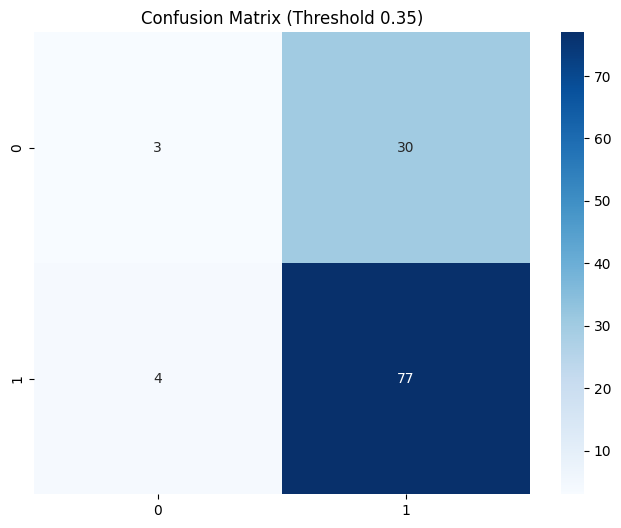

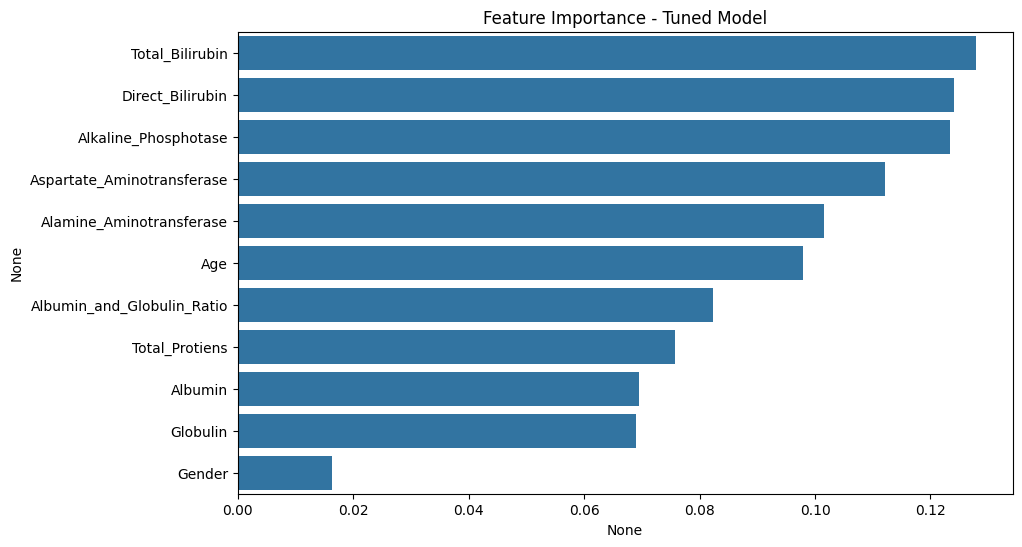

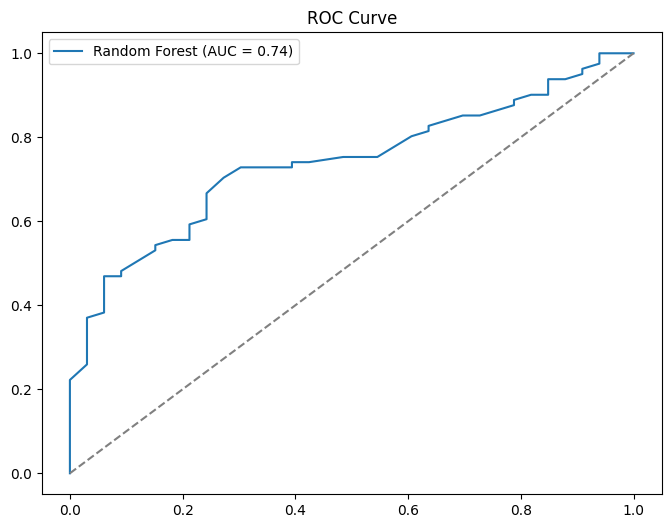

In [39]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score
import joblib

# 1. Predictions with fixed 0.35 threshold for high recall
y_prob = best_rf.predict_proba(X_test_scaled)[:, 1]
threshold = 0.35
y_pred = (y_prob >= threshold).astype(int)

# Save RF predictions for final comparison
y_pred_rf = y_pred
y_prob_rf = y_prob

# 2. Save Model & Numerical results
joblib.dump(best_rf, 'Supervised_Learning/models/best_rf_model.pkl')

cv_scores = cross_val_score(best_rf, X_train_scaled, y_train, cv=5, scoring='f1')
report = classification_report(y_test, y_pred)
print(report)
with open('Supervised_Learning/evaluation_results/rf_results.txt', 'w') as f:
    f.write(f"Best Parameters: {grid_rf.best_params_}\n")
    f.write(f"5-Fold CV F1 Score: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}\n")
    f.write("-" * 30 + "\n")
    f.write(report)

# 3. Save Visual Plots
# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix (Threshold {threshold})")
plt.savefig('Supervised_Learning/plots/rf_confusion_matrix.png')
plt.savefig('Supervised_Learning/evaluation_results/rf_confusion_matrix.png')
plt.show()

# Feature Importance
plt.figure(figsize=(10, 6))
feat_imp = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
sns.barplot(x=feat_imp, y=feat_imp.index)
plt.title("Feature Importance - Tuned Model")
plt.savefig('Supervised_Learning/plots/rf_feature_importance.png')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob):.2f})')
plt.plot([0,1],[0,1],'--', color='gray')
plt.title("ROC Curve")
plt.legend()
plt.savefig('Supervised_Learning/plots/rf_roc_curve.png')
plt.show()

# Model 2 : Logistic Regression

### Model Selection Rationale
* **Suitable for binary classification:** Specifically for predicting liver disease vs. no disease.
* **Handles small-to-medium datasets:** Works effectively with tabular data like the Indian Liver Patient Records (~583 rows).
* **Interpretable coefficients:** Provides clear insights into how each medical feature impacts the diagnosis.
* **Strong baseline model:** Serves as a perfect point of comparison for more complex models like Random Forest.
* **Efficiency:** Extremely fast to train and deploy.

###  Strengths
* **High Interpretability:** The model's coefficients directly show the impact of each feature.
* **Low Computational Cost:** Requires very little memory and processing power.
* **Linear Relationships:** Performs exceptionally well when the relationship between features is approximately linear.
* **Probability Outputs:** It doesn't just classify; it gives a probability score which is vital for medical risk prediction.
* **Robustness:** Less prone to overfitting on smaller datasets compared to deep trees.

###  Weaknesses
* **Linear Assumption:** It assumes a linear relationship between the features and the log-odds of the outcome.
* **Complexity Issues:** Might struggle with highly complex, non-linear patterns in medical data.
* **Multicollinearity:** It is sensitive to features that are highly correlated with each other.
* **Requirement for Scaling:** Needs proper feature scaling (like StandardScaler) to achieve optimal performance.
  

# Logistic Regression Data Preparation
This section prepares the dataset for training a Logistic Regression model. 
It includes loading data, splitting into features and target, train-test split, and feature scaling.

In [31]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.preprocessing import StandardScaler
import joblib

# ---------------------------------------------
# 1️⃣ Load the dataset
# ---------------------------------------------
X_train = pd.read_csv("Preprocessed_Data/X_train.csv")
X_test = pd.read_csv("Preprocessed_Data/X_test.csv")

y_train = pd.read_csv("Preprocessed_Data/y_train.csv").squeeze()
y_test = pd.read_csv("Preprocessed_Data/y_test.csv").squeeze()

# ---------------------------------------------
# 4️⃣ Feature Scaling
# Logistic Regression is sensitive to feature scales.
# StandardScaler standardizes features by removing the mean and scaling to unit variance.
# ---------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data is ready and scaled!")

✅ Data is ready and scaled!


# Logistic Regression Model Building
This section demonstrates building, training, and predicting with a Logistic Regression model for binary classification.

In [32]:
# Importing the necessary library
from sklearn.linear_model import LogisticRegression

# ------------------------------
# Step 1: Initialize the model
# ------------------------------
# Setting random_state for reproducibility and max_iter to ensure convergence
log_reg = LogisticRegression(random_state=42, max_iter=1000)

# ------------------------------
# Step 2: Train the model
# ------------------------------
# Fitting the model on scaled training features and corresponding labels
log_reg.fit(X_train_scaled, y_train)

# ------------------------------
# Step 3: Make predictions
# ------------------------------
# Predict class labels for test set
y_pred = log_reg.predict(X_test_scaled)

# Predict probabilities for the positive class
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

# Step 4: SAVE LR RESULTS
y_pred_lr = y_pred
y_prob_lr = y_prob
# ------------------------------
# Step 5: Confirmation message
# ------------------------------
print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


#  Logistic Regression Evaluation
This section evaluates the trained Logistic Regression model using key metrics, plots, cross-validation, and saves the model for future use.

Logistic Regression Classification Report:

              precision    recall  f1-score   support

           0       0.51      0.79      0.62        33
           1       0.89      0.69      0.78        81

    accuracy                           0.72       114
   macro avg       0.70      0.74      0.70       114
weighted avg       0.78      0.72      0.73       114



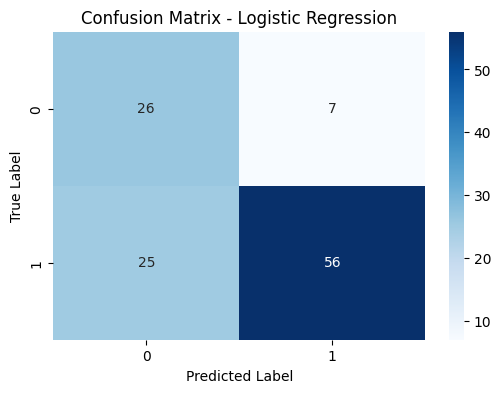

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


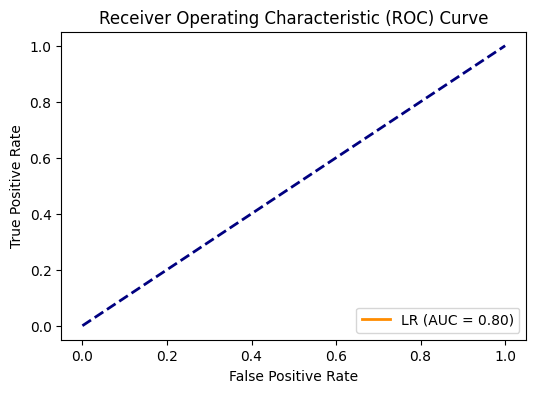

5-Fold Cross-Validation F1 Score: 0.687 ± 0.047

 All evaluation metrics generated, visualizations saved, and model exported successfully!


In [33]:
from sklearn.model_selection import cross_val_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import pandas as pd

# ==========================================
# 1. COMPREHENSIVE EVALUATION
# ==========================================
# Evaluate the Logistic Regression model using classification metrics, confusion matrix, and ROC curve

# Generate and print classification report
print("Logistic Regression Classification Report:\n")
lr_report = classification_report(y_test, y_pred)  
print(lr_report)


# Plot and save Confusion Matrix as heatmap
plt.figure(figsize=(6,4))
cm_lr = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig('Supervised_Learning/evaluation_results/lr_confusion_matrix.png')
plt.show()

# Plot and save ROC-AUC curve
# Specify pos_label=2 because y_test contains {1,2} 
lr_roc_auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=2)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'LR (AUC = {lr_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.savefig('Supervised_Learning/plots/lr_roc_curve.png')
plt.show()

# ==========================================
# 2. K-FOLD CROSS-VALIDATION (k=5)
# ==========================================
# Assess model generalization using 5-fold cross-validation on training data
cv_f1_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=5, scoring='f1')
print(f"5-Fold Cross-Validation F1 Score: {cv_f1_scores.mean():.3f} ± {cv_f1_scores.std():.3f}")

# ==========================================
# 3. MODEL PERSISTENCE & DELIVERABLES
# ==========================================
# Save trained model and scaler for future predictions or deployment
joblib.dump(log_reg, 'Supervised_Learning/models/logistic_regression_model.pkl')
joblib.dump(scaler, 'Supervised_Learning/models/lr_scaler.pkl')

# Export classification metrics to CSV for documentation and reporting
report_dict = classification_report(y_test, y_pred, output_dict=True)
pd.DataFrame(report_dict).transpose().to_csv('Supervised_Learning/evaluation_results/lr_metrics_report.csv')

# SAVE LR TO A TEXT FILE 
with open('Supervised_Learning/evaluation_results/lr_results.txt', 'w') as f:
    f.write("Logistic Regression Classification Report:\n")
    f.write(f"5-Fold CV F1 Score: {cv_f1_scores.mean():.3f} ± {cv_f1_scores.std():.3f}\n")
    f.write("-" * 30 + "\n")
    f.write(lr_report)
print("\n All evaluation metrics generated, visualizations saved, and model exported successfully!")

## Model 3: XGBoost



### 1. Model Selection Rationale

- **Handles complex relationships:** Medical features such as Bilirubin levels and liver enzymes can affect the disease in complicated ways. XGBoost can learn these patterns well.
- **High performance on tabular data:** XGBoost is known to work very well on structured datasets like medical records.
- **Reduces overfitting:** XGBoost includes regularization techniques that help prevent the model from fitting the training data too closely.
- **Improves predictions step by step:** The model builds trees one by one and corrects mistakes from previous trees.


### Strengths

- **High accuracy:** Often performs very well on prediction tasks.
- **Works well with complex data:** Can capture relationships between multiple medical features.
- **Efficient algorithm:** Designed to train models faster than many other boosting methods.


### Weaknesses

- **Harder to interpret:** It is more difficult to explain the effect of each feature compared to Logistic Regression.
- **Needs parameter tuning:** The model may require adjusting several parameters to achieve the best results.
- **Higher computational cost:** Training may take longer than simpler models.

### Imports

In this section, we import the libraries required to implement and evaluate the **XGBoost model**. These libraries support data handling, visualization, machine learning algorithms, and performance evaluation.

**Description of the libraries used:**

- **pandas** – used to load and manipulate the dataset.
- **numpy** – supports numerical operations.
- **matplotlib & seaborn** – used to create visualizations such as confusion matrices and ROC curves.
- **XGBoost (XGBClassifier)** – the machine learning algorithm used to train the XGBoost model.
- **scikit-learn metrics** – used to evaluate model performance using metrics such as accuracy, precision, recall, and ROC-AUC.
- **cross_val_score** – used to perform cross-validation to measure model stability.
- **StandardScaler** – standardizes feature values so models can learn more effectively.
- **joblib** – used to save the trained model for future use.

In [34]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

import joblib

### Data Preparation

In this step, we load the already preprocessed datasets prepared during the earlier phase of the project. The data has already been cleaned and split into **training and testing sets** by the team.

We then apply **feature scaling** using **StandardScaler** to ensure consistent feature ranges across all models used in the project. This step helps improve model performance and keeps preprocessing consistent across the different algorithms implemented by the team.

In [35]:
### XGBoost Data Preparation


# Load preprocessed and already-split datasets
X_train = pd.read_csv("Preprocessed_Data/X_train.csv")
X_test = pd.read_csv("Preprocessed_Data/X_test.csv")

y_train = pd.read_csv("Preprocessed_Data/y_train.csv").squeeze()
y_test = pd.read_csv("Preprocessed_Data/y_test.csv").squeeze()

# Feature scaling (kept consistent with other models)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data loaded and ready for XGBoost training")

Data loaded and ready for XGBoost training


### XGBoost Model Building

In [36]:
# Initialize the XGBoost model
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Train the model
xgb_model.fit(X_train_scaled, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


### XGBoost Evaluation
This section evaluates the XGBoost model using classification metrics, confusion matrix, ROC-AUC, and cross-validation. These results help measure how well the model predicts liver disease and how reliable it is compared to the other models.

XGBoost Classification Report:

              precision    recall  f1-score   support

           0       0.50      0.36      0.42        33
           1       0.77      0.85      0.81        81

    accuracy                           0.71       114
   macro avg       0.63      0.61      0.61       114
weighted avg       0.69      0.71      0.70       114



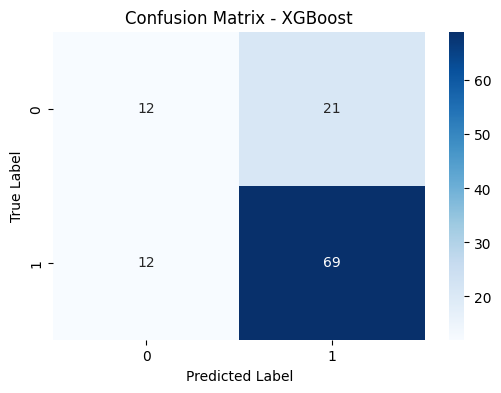

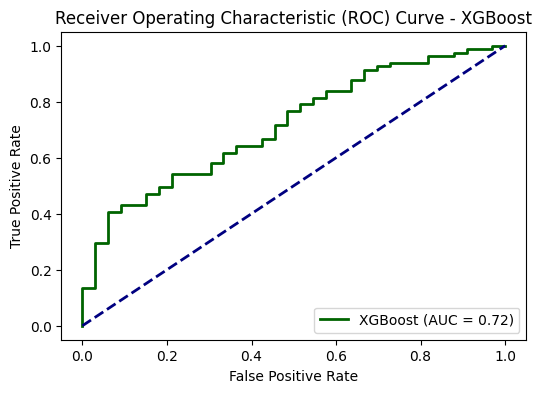

5-Fold Cross-Validation F1 Score: 0.793 ± 0.076


In [37]:
# Make predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Print classification report
print("XGBoost Classification Report:\n")
xgb_report = classification_report(y_test, y_pred_xgb)
print(xgb_report)



# Confusion Matrix
plt.figure(figsize=(6,4))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig('Supervised_Learning/evaluation_results/xgb_confusion_matrix.png')
plt.show()

# ROC Curve
xgb_roc_auc = roc_auc_score(y_test, y_prob_xgb)
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkgreen', lw=2, label=f'XGBoost (AUC = {xgb_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title("Receiver Operating Characteristic (ROC) Curve - XGBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.savefig('Supervised_Learning/plots/xgb_roc_curve.png')
plt.show()

# 5-Fold Cross-Validation
cv_f1_scores_xgb = cross_val_score(xgb_model, X_train_scaled, y_train, cv=5, scoring='f1')
print(f"5-Fold Cross-Validation F1 Score: {cv_f1_scores_xgb.mean():.3f} ± {cv_f1_scores_xgb.std():.3f}")

#  SAVE XGB TO A TEXT FILE 
with open('Supervised_Learning/evaluation_results/xgb_results.txt', 'w') as f:
    f.write("XGBoost Classification Report:\n")
    f.write(f"5-Fold CV F1 Score: {cv_f1_scores_xgb.mean():.3f} ± {cv_f1_scores_xgb.std():.3f}\n")
    f.write("-" * 30 + "\n")
    f.write(xgb_report)

## Model Performance Comparison

To better evaluate the performance of the implemented models, we compute several evaluation metrics for each algorithm. These metrics allow us to compare how well the models classify patients with and without liver disease.

The following metrics are used:

- **Accuracy:** Measures the overall percentage of correctly classified predictions.
- **Recall:** Indicates how well the model identifies patients who actually have liver disease.
- **F1-Score:** Provides a balance between precision and recall, which is useful when dealing with class imbalance.
- **ROC-AUC:** Measures the model's ability to distinguish between positive and negative classes across different decision thresholds.

After calculating these metrics for **Random Forest, Logistic Regression, and XGBoost**, we summarize the results in a comparison table. This table helps identify which model performs best and supports the final model selection for the liver disease prediction system.

In [38]:

from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score
import pandas as pd

models = {
    "Random Forest": (y_pred_rf, y_prob_rf),
    "Logistic Regression": (y_pred_lr, y_prob_lr),
    "XGBoost": (y_pred_xgb, y_prob_xgb)
}

results = []

for model_name, (pred, prob) in models.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

results_df = pd.DataFrame(results)
display(results_df)

,Model,Accuracy,Recall,F1 Score,ROC-AUC
0,Random Forest,0.701754,0.950617,0.819149,0.739431
1,Logistic Regression,0.719298,0.691358,0.777778,0.800973
2,XGBoost,0.710526,0.851852,0.807018,0.715675


## Comparative Analysis and Final Recommendation

Random Forest achieved the highest recall (**0.95**), indicating a strong ability to detect liver disease cases. However, its accuracy was slightly lower due to an increased number of false positives. Logistic Regression achieved the highest accuracy (**0.72**) and the best **ROC-AUC score (0.80)**, demonstrating a more balanced classification performance. XGBoost produced results similar to Random Forest, with strong recall and F1 score but slightly lower ROC-AUC.

Overall, Logistic Regression provided the most stable performance, while Random Forest and XGBoost were more effective at detecting positive cases.

The final model selection depends on the **priority defined by medical experts**. If the main objective is **maximizing disease detection**, then **Random Forest** is the preferred model because it achieved the highest recall (**0.95**). This means the model can identify most patients who actually have liver disease, which is important in medical screening where missing a positive case could delay treatment.

On the other hand, if the goal is to achieve a more **balanced overall performance**, **Logistic Regression** can be considered the recommended model because it achieved the highest accuracy (**0.72**) and **ROC-AUC score (0.80)**. Additionally, Logistic Regression is easier to interpret, allowing healthcare professionals to better understand how different medical features influence predictions.

Therefore, the final model choice should be guided by the **doctor’s priority** between maximizing disease detection (**Random Forest**) or maintaining balanced predictive performance and interpretability (**Logistic Regression**).